# 0 Configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# =====================================
# Runtime Information
# =====================================

import platform
import psutil
import torch

print("=" * 50)
print("Python :", platform.python_version())
print("RAM    :", round(psutil.virtual_memory().total / (1024**3),2),"GB")
print("GPU    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Python : 3.12.13
RAM    : 12.67 GB
GPU    : True
Tesla T4


In [2]:
# =====================================
# Runtime Configuration
# =====================================

import warnings
import random
import gc

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Runtime configured successfully.")

Runtime configured successfully.


In [3]:
import torch

USE_GPU = torch.cuda.is_available()

DEVICE = "cuda" if USE_GPU else "cpu"

print(f"Device : {DEVICE}")

if USE_GPU:
    print(torch.cuda.get_device_name(0))

Device : cuda
Tesla T4


In [4]:
!pip -q install kagglehub

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rizalkurnia198/ieee-cis-fraud-detection-memory-optimized-dataset")

print("Path to dataset files:", path)

100%|██████████| 51.0M/51.0M [00:00<00:00, 143MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rizalkurnia198/ieee-cis-fraud-detection-memory-optimized-dataset/versions/1


# 01 Introduction

## Objective

Develop and evaluate multiple machine learning models to predict fraudulent transactions using the feature-engineered dataset. The objective of this notebook is to identify the model that provides the best predictive performance before integrating it into the Fraud Detection Decision Engine.

## Business Question

**Which machine learning model provides the best fraud prediction performance for identifying fraudulent transactions?**

# 02 Dataset Preparation

## Objective

Prepare the feature-engineered dataset for machine learning by loading the processed data, verifying its integrity, separating features from the target variable, and creating training and testing datasets.

### 2.1 Load Feature Engineered Dataset

The feature-engineered dataset generated in the previous notebook is loaded as the input for model development. This dataset has completed feature selection and missing value treatment, making it ready for machine learning experiments.

In [5]:
import pandas as pd
import os

file_path = os.path.join(path, 'data_optimized.parquet')
df = pd.read_parquet(file_path)

### 2.2 Dataset Verification

Before model development begins, the dataset is verified to ensure that it has been loaded correctly and remains consistent with the output produced during the Feature Engineering stage.

In [7]:
print(df.shape)

print(df["isFraud"].value_counts())

df.head()

(590540, 434)
isFraud
0    569877
1     20663
Name: count, dtype: int64


,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,card5_group,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,credit,315.0,87.0,19.0,37.0,Missing,Missing,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,97.0,13.0,26.0,10.0,0.0,0.0,37.875,0.666666,13.0,13.0,0.0,0.0,0.0,0.0,T,T,T,M2,F,T,Missing,Missing,Missing,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Other,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,Missing,-999.0,-999.0,Missing,Missing,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,Missing,-999.0,-999.0,-999.0,Missing,Missing,Missing,Missing,Missing,-999.0,Missing,Missing

### 2.3 Feature and Target Separation

The dataset is divided into predictor variables (`X`) and the target variable (`y`).

The target variable is `isFraud`, where:

- `0` represents legitimate transactions.
- `1` represents fraudulent transactions.

All remaining features are treated as predictor variables and will be used for model training.

In [6]:
# Separate features and target

X = df.drop(columns="isFraud")
y = df["isFraud"]

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")

Feature matrix shape : (590540, 433)
Target vector shape  : (590540,)


### 2.4 Train-Test Split

The dataset is divided into training and testing subsets to evaluate model performance on unseen data.

A stratified split is used to preserve the original fraud distribution in both subsets, ensuring that the class imbalance remains consistent throughout model training and evaluation.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set : {X_train.shape}")
print(f"Testing set  : {X_test.shape}")

Training set : (472432, 433)
Testing set  : (118108, 433)


### 2.5 Class Distribution

The fraud distribution is examined after the train-test split to verify that the stratified sampling strategy successfully preserves the original class distribution in both the training and testing datasets.

Maintaining a consistent fraud proportion is important because the dataset is highly imbalanced. Without stratification, model evaluation could become biased due to different fraud distributions between the training and testing sets.

In [10]:
distribution = pd.DataFrame({
    "Dataset": ["Original", "Training", "Testing"],
    "Transactions": [
        len(y),
        len(y_train),
        len(y_test)
    ],
    "Fraud": [
        y.sum(),
        y_train.sum(),
        y_test.sum()
    ]
})

distribution["Legitimate"] = (
    distribution["Transactions"] - distribution["Fraud"]
)

distribution["Fraud Rate (%)"] = (
    distribution["Fraud"] / distribution["Transactions"] * 100
).round(2)

distribution

,Dataset,Transactions,Fraud,Legitimate,Fraud Rate (%)
0,Original,590540,20663,569877,3.5
1,Training,472432,16530,455902,3.5
2,Testing,118108,4133,113975,3.5


In [11]:
# =====================================
# Memory Optimization
# =====================================

float_columns = X_train.select_dtypes(include="float64").columns
int_columns = X_train.select_dtypes(include="int64").columns

X_train[float_columns] = X_train[float_columns].astype("float32")
X_test[float_columns] = X_test[float_columns].astype("float32")

X_train[int_columns] = X_train[int_columns].astype("int32")
X_test[int_columns] = X_test[int_columns].astype("int32")

print("Memory optimization completed.")

Memory optimization completed.


In [12]:
print(X_train.dtypes.value_counts())

float32     399
category     12
category      4
int32         1
category      1
category      1
int16         1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Name: count, dtype: int64


The class distribution remains identical across the original, training, and testing datasets. This confirms that the stratified train-test split successfully preserved the original fraud proportion, ensuring that both subsets are representative of the overall dataset.

Maintaining a consistent class distribution is particularly important for this highly imbalanced fraud detection problem, as it allows model training and evaluation to be performed under comparable data conditions.

# 03 Data Preprocessing

## Objective

Prepare the training and testing datasets according to the requirements of the selected machine learning algorithms by transforming categorical variables into numerical representations and applying appropriate feature scaling where necessary.

---

### 3.1 Preprocessing Strategy

The selected machine learning algorithms consist primarily of tree-based ensemble models, including Random Forest, XGBoost, and LightGBM, with Logistic Regression serving as the baseline model.

To ensure a fair comparison between algorithms, all candidate models are trained using the same preprocessing pipeline. Therefore, **Ordinal Encoding** is applied to all categorical variables instead of using different encoding techniques for different models.

This decision is based on several considerations:

- Tree-based algorithms naturally handle integer-encoded categorical variables and generally perform well with Ordinal Encoding.
- Using a single preprocessing strategy ensures that performance differences originate from the learning algorithms rather than differences in data preprocessing.
- Ordinal Encoding preserves the original feature dimensionality, avoiding the feature expansion introduced by One-Hot Encoding and resulting in a more memory-efficient training process.
- The dataset contains several categorical features that may produce previously unseen categories in future transactions. Using `OrdinalEncoder` with unknown category handling provides a more robust preprocessing pipeline by preventing transformation failures during model inference.
- The dataset contains relatively few categorical features with low cardinality, making Ordinal Encoding an appropriate and efficient choice.

Although One-Hot Encoding is generally more suitable for linear models such as Logistic Regression, maintaining a consistent preprocessing pipeline across all candidate models is considered more important for this comparative study.

---

### 3.2 Categorical Encoding

All categorical variables are transformed into numerical values using Label Encoding.

The encoder is fitted using the training dataset and subsequently applied to the testing dataset to prevent information leakage from the testing data into the training process.

Separate encoders are maintained for each categorical feature to preserve the mapping between original categories and encoded values.

In [8]:
# Compatible with Pandas 2.x and Pandas 3.x string dtypes

categorical_columns = [
    col for col in X_train.columns
    if (
        X_train[col].dtype == "object"
        or pd.api.types.is_string_dtype(X_train[col])
        or str(X_train[col].dtype) == "category"
    )
]

In [11]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[categorical_columns] = encoder.fit_transform(
    X_train[categorical_columns].astype(str)
)

X_test[categorical_columns] = encoder.transform(
    X_test[categorical_columns].astype(str)
)

print("Ordinal Encoding completed successfully.")

Ordinal Encoding completed successfully.


In [12]:
X_train[categorical_columns] = (
    X_train[categorical_columns]
    .astype("float32")
)

X_test[categorical_columns] = (
    X_test[categorical_columns]
    .astype("float32")
)

In [13]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

### 3.3 Dataset Verification

The dataset is verified after categorical encoding to ensure that all categorical variables have been successfully transformed into numerical representations before model training.

In [21]:
X_train[categorical_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 472432 entries, 40809 to 337290
Data columns (total 32 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ProductCD      472432 non-null  float32
 1   card4          472432 non-null  float32
 2   card6          472432 non-null  float32
 3   P_emaildomain  472432 non-null  float32
 4   R_emaildomain  472432 non-null  float32
 5   M1             472432 non-null  float32
 6   M2             472432 non-null  float32
 7   M3             472432 non-null  float32
 8   M4             472432 non-null  float32
 9   M5             472432 non-null  float32
 10  M6             472432 non-null  float32
 11  M7             472432 non-null  float32
 12  M8             472432 non-null  float32
 13  M9             472432 non-null  float32
 14  card5_group    472432 non-null  float32
 15  id_12          472432 non-null  float32
 16  id_15          472432 non-null  float32
 17  id_16          472432 non-null

In [17]:
print(f"Encoded categorical features : {len(categorical_columns)}")
print(f"Training shape : {X_train.shape}")
print(f"Testing shape  : {X_test.shape}")

Encoded categorical features : 32
Training shape : (472432, 433)
Testing shape  : (118108, 433)


In [24]:
print(X_train.dtypes.value_counts())

print(X_train.memory_usage(deep=True).sum() / 1024**2)

float32    433
Name: count, dtype: int64
783.9505004882812


In [25]:
import psutil

print(X_train.shape)
print(X_train.memory_usage(deep=True).sum() / 1024**2)
print(y_train.memory_usage(deep=True) / 1024**2)

print(f"Available RAM : {psutil.virtual_memory().available / 1024**3:.2f} GB")
print(f"Used RAM      : {psutil.virtual_memory().used / 1024**3:.2f} GB")

(472432, 433)
783.9505004882812
4.0549163818359375
Available RAM : 4.88 GB
Used RAM      : 7.51 GB


# 04 Model Development

This section develops multiple candidate machine learning models for fraud classification.

Logistic Regression is first trained as a baseline classifier to establish a reference performance before evaluating more advanced tree-based ensemble algorithms. Subsequently, Random Forest, XGBoost, and LightGBM are trained using the complete training dataset and compared using the same evaluation metrics.

The best-performing model will be selected for deployment in the Fraud Detection Decision Engine.

## 4.1 Logistic Regression (Baseline)

Logistic Regression is employed as the baseline classifier to provide a simple and interpretable benchmark before evaluating more sophisticated tree-based ensemble algorithms.

As a linear classification algorithm, Logistic Regression assumes that all numerical features are measured on a comparable scale. Therefore, feature scaling is performed prior to model training to prevent variables with larger numerical ranges from dominating the optimization process.

The scaled dataset is used exclusively for Logistic Regression, while tree-based models in the subsequent sections are trained using the original feature values since they are inherently insensitive to feature scaling.

### 4.1.1 Feature Scaling

Logistic Regression is an optimization-based algorithm that is sensitive to differences in feature magnitudes. Numerical variables with substantially larger scales may dominate the optimization process and slow convergence during parameter estimation.

To ensure that all numerical features contribute equally during training, **StandardScaler** is applied to the numerical variables by transforming each feature into a standardized distribution with zero mean and unit variance.

Categorical variables are excluded from this process because they have already been transformed using Ordinal Encoding during the preprocessing stage.

In [18]:
# =====================================
# Identify Numerical Features
# =====================================

numerical_columns = [
    col for col in X_train.columns
    if col not in categorical_columns
]

print(f"Numerical features : {len(numerical_columns)}")

Numerical features : 401


In [19]:
# =====================================
# Feature Scaling
# Logistic Regression Only
# =====================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test_scaled[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [29]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000,
    solver="saga"
)

lr_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression training completed successfully.")

Logistic Regression training completed successfully.


### 4.1.2 Evaluation

In [53]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Prediction

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Prediction completed successfully.")

Prediction completed successfully.


In [54]:
print("=" * 60)
print("Classification Report")
print("=" * 60)

print(classification_report(y_test, y_pred, digits=4))

Classification Report
              precision    recall  f1-score   support

           0     0.9880    0.8266    0.9002    113975
           1     0.1315    0.7242    0.2226      4133

    accuracy                         0.8230    118108
   macro avg     0.5598    0.7754    0.5614    118108
weighted avg     0.9581    0.8230    0.8764    118108



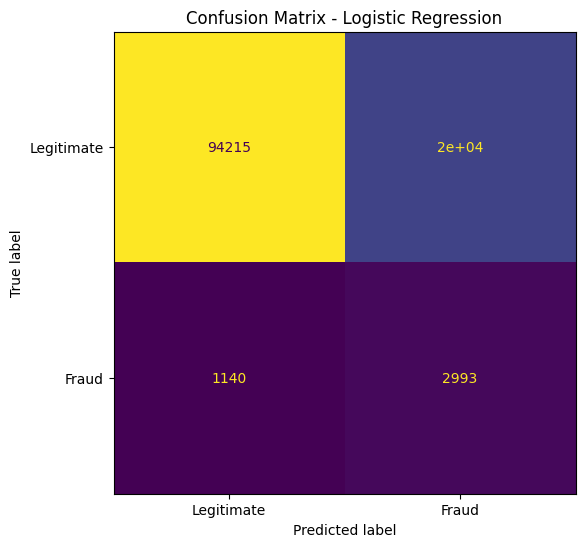

In [55]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, colorbar=False)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

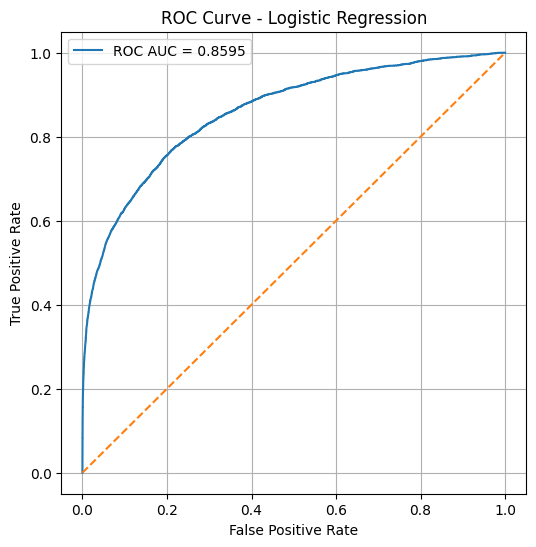

ROC-AUC Score : 0.8595


In [56]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.grid(True)

plt.show()

print(f"ROC-AUC Score : {roc_auc:.4f}")

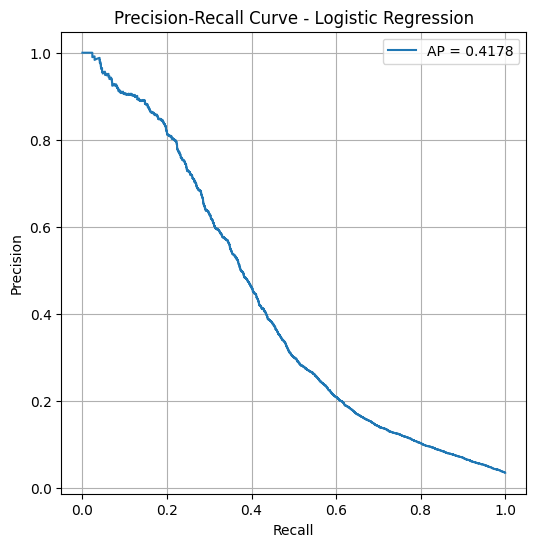

Average Precision : 0.4178


In [57]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob_lr
)

ap_score = average_precision_score(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"AP = {ap_score:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")

plt.legend()
plt.grid(True)

plt.show()

print(f"Average Precision : {ap_score:.4f}")

### 4.1.3 Threshold Optimization

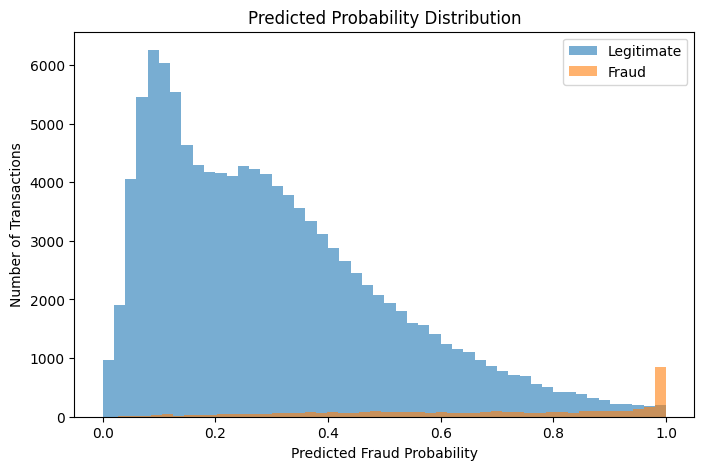

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    y_prob_lr[y_test == 0],
    bins=50,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    y_prob_lr[y_test == 1],
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Number of Transactions")

plt.title("Predicted Probability Distribution")
plt.legend()

plt.show()

In [59]:
import numpy as np

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.10, 0.95, 0.05)

results = []

for threshold in thresholds:

    pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

In [60]:
import pandas as pd

threshold_result = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

threshold_result

,Threshold,Precision,Recall,F1 Score
0,0.10,0.040952,0.984999,0.078634
1,0.15,0.046797,0.967094,0.089274
2,0.20,0.052694,0.951125,0.099855
3,0.25,0.059611,0.924510,0.112000
4,0.30,0.069517,0.899589,0.129061
5,0.35,0.081084,0.859908,0.148194
6,0.40,0.095599,0.819985,0.171235
7,0.45,0.112713,0.777401,0.196881
8,0.50,0.131543,0.724171,0.222644
9,0.55,0.155738,0.675780,0.253138


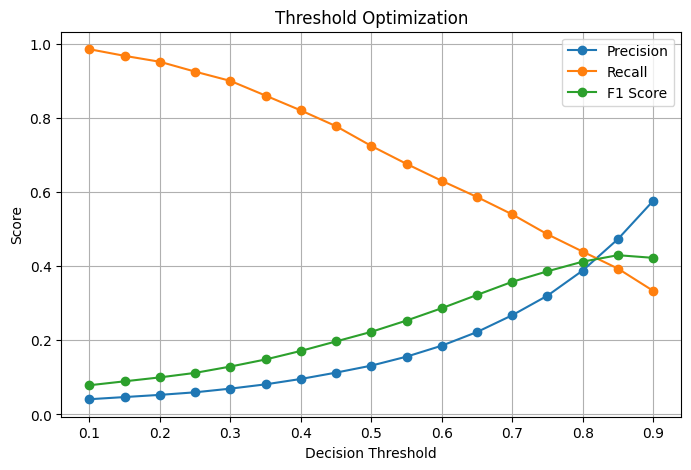

In [61]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_result["Threshold"],
    threshold_result["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_result["Threshold"],
    threshold_result["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_result["Threshold"],
    threshold_result["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")

plt.title("Threshold Optimization")

plt.grid(True)
plt.legend()

plt.show()

### 4.1.4 Save Artifak

In [63]:
# =====================================
# Logistic Regression
# Save Model & Artifacts
# =====================================

import os
import joblib

# Folder penyimpanan
SAVE_DIR = "/content/drive/MyDrive/Projects/DataAnalyst/fraud_detection/Model"

os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------------------------------------
# 1. Model
# -------------------------------------------------
joblib.dump(
    lr_model,
    f"{SAVE_DIR}/logistic_regression_model.pkl"
)

# -------------------------------------------------
# 2. Standard Scaler
# -------------------------------------------------
joblib.dump(
    scaler,
    f"{SAVE_DIR}/logistic_regression_scaler.pkl"
)

# -------------------------------------------------
# 3. Prediction Probability
# -------------------------------------------------
joblib.dump(
    y_prob_lr,
    f"{SAVE_DIR}/logistic_regression_probability.pkl"
)

# -------------------------------------------------
# 4. Threshold Result
# -------------------------------------------------
threshold_result.to_csv(
    f"{SAVE_DIR}/logistic_regression_threshold.csv",
    index=False
)

print("=====================================")
print("Logistic Regression artifacts saved.")
print("=====================================")

Logistic Regression artifacts saved.


## 4.2 Random Forest

### 4.2.1 Training

In [45]:
# =====================================
# Random Forest
# Model Training
# =====================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed successfully.")

Random Forest training completed successfully.


### 4.2.2 Evaluation

Classification Report
              precision    recall  f1-score   support

           0     0.9789    0.9992    0.9889    113975
           1     0.9463    0.4050    0.5673      4133

    accuracy                         0.9784    118108
   macro avg     0.9626    0.7021    0.7781    118108
weighted avg     0.9777    0.9784    0.9742    118108



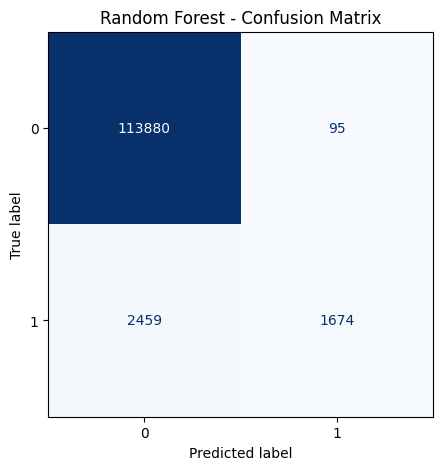

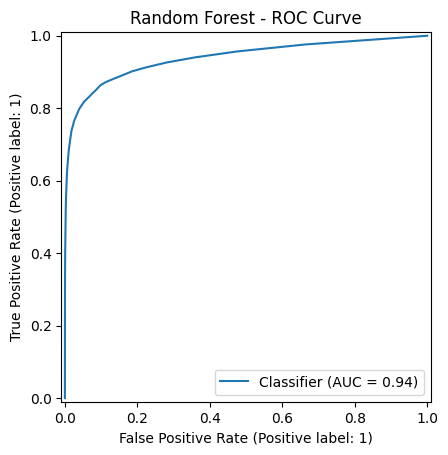

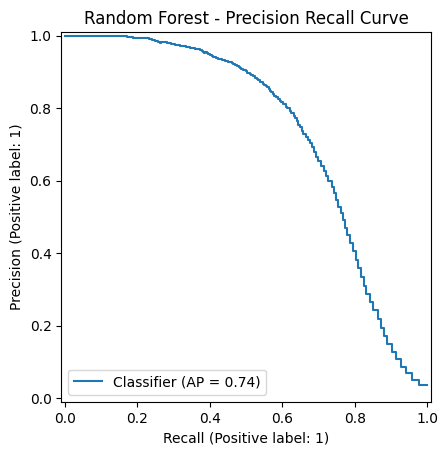

In [47]:
# =====================================
# Random Forest
# Model Evaluation
# =====================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Probability
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Classification Report
print("=" * 60)
print("Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, digits=4))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues",
    ax=ax,
    colorbar=False
)

ax.set_title("Random Forest - Confusion Matrix")
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_proba_rf
)

plt.title("Random Forest - ROC Curve")
plt.show()

# Precision Recall Curve
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_rf
)

plt.title("Random Forest - Precision Recall Curve")
plt.show()

### 4.2.3 Threshold Optimization

In [49]:
# =====================================
# Random Forest
# Threshold Optimization
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:

    y_pred_threshold = (y_proba_rf >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_result = pd.DataFrame(results)

threshold_result

,Threshold,Precision,Recall,F1 Score
0,0.10,0.469278,0.779821,0.585947
1,0.15,0.654260,0.706025,0.679157
2,0.20,0.754574,0.648681,0.697632
3,0.25,0.820871,0.597629,0.691683
4,0.30,0.864855,0.554319,0.675612
5,0.35,0.893939,0.513912,0.652635
6,0.40,0.915858,0.479313,0.629288
7,0.45,0.932247,0.442778,0.600394
8,0.50,0.946297,0.405033,0.567265
9,0.55,0.959484,0.378176,0.542520


### 4.2.4 Save Artifak

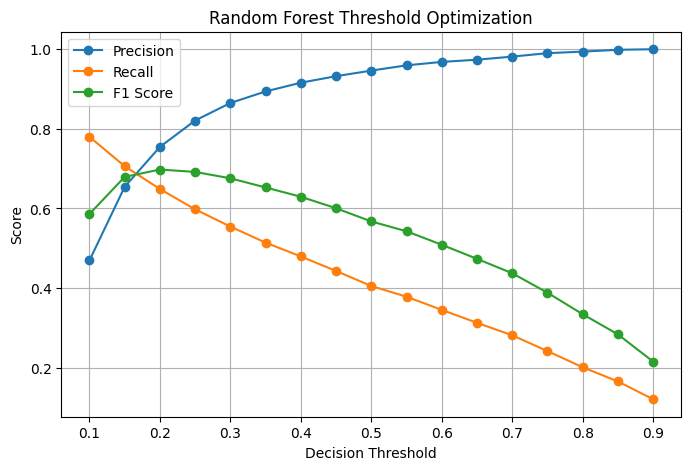

In [50]:
# =====================================
# Threshold Optimization Visualization
# =====================================

plt.figure(figsize=(8,5))

plt.plot(
    threshold_result["Threshold"],
    threshold_result["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_result["Threshold"],
    threshold_result["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_result["Threshold"],
    threshold_result["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Random Forest Threshold Optimization")

plt.grid(True)
plt.legend()

plt.show()

In [51]:
# =====================================
# Save Random Forest Progress
# =====================================

SAVE_DIR = "/content/drive/MyDrive/Projects/DataAnalyst/fraud_detection/Model"

os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Model
joblib.dump(
    rf_model,
    f"{SAVE_DIR}/random_forest_model.pkl"
)

# 2. Prediction Probability
joblib.dump(
    y_proba_rf,
    f"{SAVE_DIR}/random_forest_probability.pkl"
)

# 3. Threshold Optimization Result
joblib.dump(
    threshold_result,
    f"{SAVE_DIR}/random_forest_threshold.pkl"
)

print("=" * 60)
print("Random Forest progress saved successfully.")
print(f"Model       : {SAVE_DIR}/random_forest_model.pkl")
print(f"Probability : {SAVE_DIR}/random_forest_probability.pkl")
print(f"Threshold   : {SAVE_DIR}/random_forest_threshold.pkl")
print("=" * 60)

Random Forest progress saved successfully.
Model       : /content/drive/MyDrive/Projects/DataAnalyst/fraud_detection/Model/random_forest_model.pkl
Probability : /content/drive/MyDrive/Projects/DataAnalyst/fraud_detection/Model/random_forest_probability.pkl
Threshold   : /content/drive/MyDrive/Projects/DataAnalyst/fraud_detection/Model/random_forest_threshold.pkl


## 4.3 XGBoost

### 4.3.1 Training

In [64]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda"
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed successfully.")

XGBoost training completed successfully.


### 4.3.2 Evaluation

Classification Report
              precision    recall  f1-score   support

           0     0.9804    0.9985    0.9893    113975
           1     0.9133    0.4488    0.6019      4133

    accuracy                         0.9792    118108
   macro avg     0.9469    0.7236    0.7956    118108
weighted avg     0.9780    0.9792    0.9758    118108



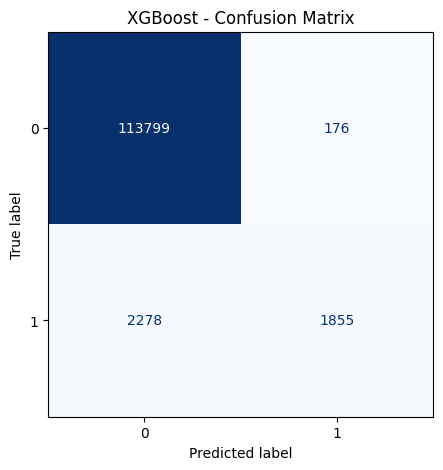

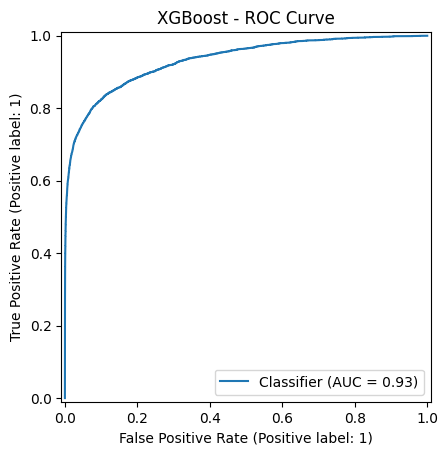

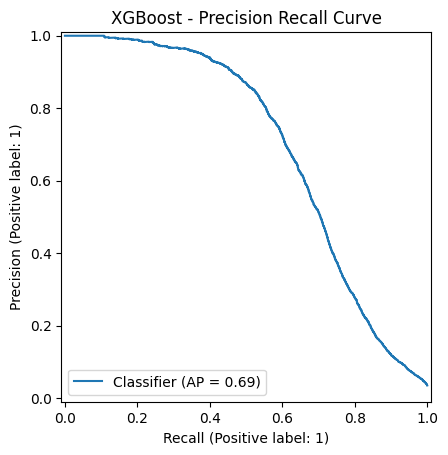

In [65]:
# =====================================
# XGBoost
# Model Evaluation
# =====================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt

# -------------------------------------
# Prediction
# -------------------------------------

y_pred_xgb = xgb_model.predict(X_test)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# -------------------------------------
# Classification Report
# -------------------------------------

print("=" * 60)
print("Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_xgb, digits=4))

# -------------------------------------
# Confusion Matrix
# -------------------------------------

fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title("XGBoost - Confusion Matrix")

plt.show()

# -------------------------------------
# ROC Curve
# -------------------------------------

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_xgb
)

plt.title("XGBoost - ROC Curve")
plt.show()

# -------------------------------------
# Precision Recall Curve
# -------------------------------------

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_xgb
)

plt.title("XGBoost - Precision Recall Curve")
plt.show()

### 4.3.3 Threshold Optimization

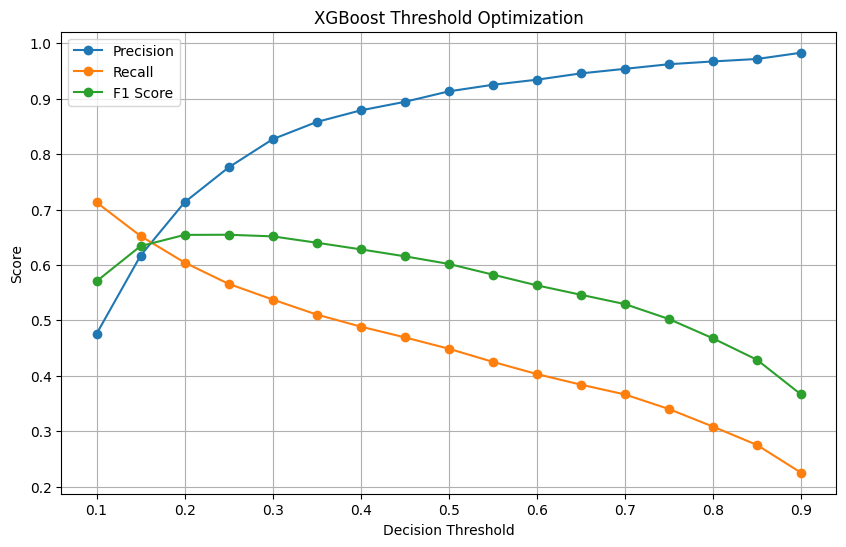

,Threshold,Precision,Recall,F1 Score
0,0.10,0.475476,0.713041,0.570516
1,0.15,0.616792,0.652311,0.634055
2,0.20,0.713103,0.604404,0.654269
3,0.25,0.776045,0.565933,0.654540
4,0.30,0.826945,0.537624,0.651613
5,0.35,0.858072,0.510525,0.640170
6,0.40,0.879025,0.488749,0.628207
7,0.45,0.894421,0.469393,0.615678
8,0.50,0.913343,0.448827,0.601882
9,0.55,0.925224,0.425115,0.582560


In [66]:
# =====================================
# XGBoost
# Threshold Optimization
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.10, 0.91, 0.05)

precision_list = []
recall_list = []
f1_list = []

for threshold in thresholds:

    y_pred_threshold = (y_proba_xgb >= threshold).astype(int)

    precision_list.append(
        precision_score(y_test, y_pred_threshold)
    )

    recall_list.append(
        recall_score(y_test, y_pred_threshold)
    )

    f1_list.append(
        f1_score(y_test, y_pred_threshold)
    )

threshold_result_xgb = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1 Score": f1_list
})

# =====================================
# Visualization
# =====================================

plt.figure(figsize=(10,6))

plt.plot(
    thresholds,
    precision_list,
    marker="o",
    label="Precision"
)

plt.plot(
    thresholds,
    recall_list,
    marker="o",
    label="Recall"
)

plt.plot(
    thresholds,
    f1_list,
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold Optimization")

plt.grid(True)
plt.legend()

plt.show()

display(threshold_result_xgb)

### 4.3.4 Save Model & Artifacts

In [67]:
# =====================================
# Save XGBoost Artifacts
# =====================================

import joblib

SAVE_DIR = "/content/drive/MyDrive/Projects/DataAnalyst/fraud_detection/Model"

# 1. Model
joblib.dump(
    xgb_model,
    f"{SAVE_DIR}/xgboost_fraud_model.pkl"
)

# 2. Prediction Probability
joblib.dump(
    y_proba_xgb,
    f"{SAVE_DIR}/xgboost_probability.pkl"
)

# 3. Prediction
joblib.dump(
    y_pred_xgb,
    f"{SAVE_DIR}/xgboost_prediction.pkl"
)

# 4. Threshold Result
joblib.dump(
    threshold_result_xgb,
    f"{SAVE_DIR}/xgboost_threshold_result.pkl"
)

print("=====================================")
print("XGBoost artifacts saved successfully.")
print("=====================================")

XGBoost artifacts saved successfully.


## 4.4 LightBGM

### 4.4.1 Training

In [14]:
from lightgbm import LGBMClassifier

# =====================================
# LightGBM Training
# =====================================

lgbm_model = LGBMClassifier(
    random_state=42,

    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,

    class_weight="balanced"
)

lgbm_model.fit(
    X_train,
    y_train
)

print("LightGBM training completed successfully.")

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.091485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 38814
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 431
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM training completed successfully.


### 4.4.2 Evaluation

In [18]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt


In [15]:
# =====================================
# Prediction
# =====================================

y_pred_lgbm = lgbm_model.predict(X_test)
y_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

print("Prediction completed successfully.")

Prediction completed successfully.


Classification Report
              precision    recall  f1-score   support

           0     0.9927    0.9032    0.9458    113975
           1     0.2345    0.8180    0.3645      4133

    accuracy                         0.9002    118108
   macro avg     0.6136    0.8606    0.6552    118108
weighted avg     0.9662    0.9002    0.9255    118108



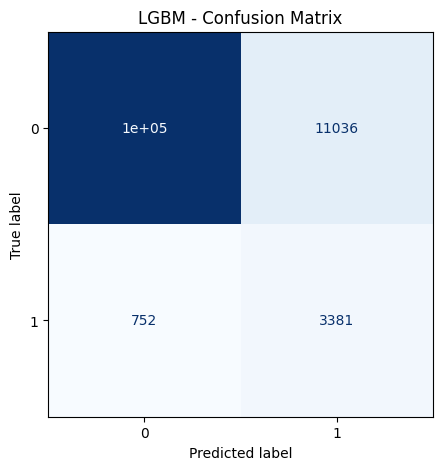

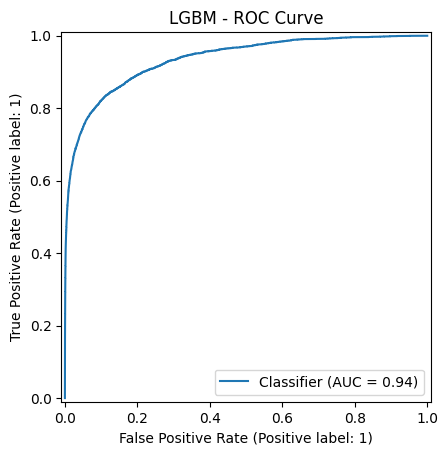

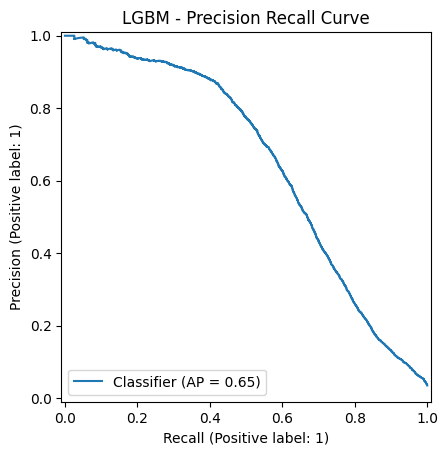

In [19]:
# -------------------------------------
# Classification Report
# -------------------------------------

print("=" * 60)
print("Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_lgbm, digits=4))

# -------------------------------------
# Confusion Matrix
# -------------------------------------

fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lgbm,
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title("LGBM - Confusion Matrix")

plt.show()

# -------------------------------------
# ROC Curve
# -------------------------------------

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_lgbm
)

plt.title("LGBM - ROC Curve")
plt.show()

# -------------------------------------
# Precision Recall Curve
# -------------------------------------

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_lgbm
)

plt.title("LGBM - Precision Recall Curve")
plt.show()

### 4.4.3 Threshold Optimization

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_result_lgbm = []

for threshold in thresholds:

    y_pred_threshold = (
        y_proba_lgbm >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold
    )

    recall = recall_score(
        y_test,
        y_pred_threshold
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    threshold_result_lgbm.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_result_lgbm = pd.DataFrame(
    threshold_result_lgbm,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

threshold_result_lgbm

,Threshold,Precision,Recall,F1 Score
0,0.10,0.051267,0.990806,0.097490
1,0.15,0.066784,0.969272,0.124959
2,0.20,0.086682,0.951367,0.158888
3,0.25,0.107731,0.925478,0.192997
4,0.30,0.128830,0.901282,0.225436
5,0.35,0.150878,0.879023,0.257550
6,0.40,0.174692,0.856763,0.290210
7,0.45,0.202545,0.839584,0.326358
8,0.50,0.234515,0.818050,0.364528
9,0.55,0.272773,0.793370,0.405968


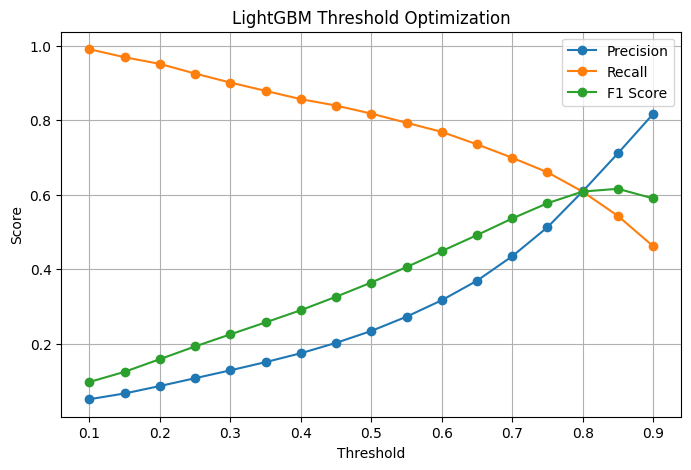

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    threshold_result_lgbm["Threshold"],
    threshold_result_lgbm["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_result_lgbm["Threshold"],
    threshold_result_lgbm["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_result_lgbm["Threshold"],
    threshold_result_lgbm["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("LightGBM Threshold Optimization")

plt.grid(True)
plt.legend()

plt.show()

### 4.4.4 Save Artifak

In [22]:
import joblib
import os

SAVE_DIR = "/content/drive/MyDrive/Projects/DataAnalyst/fraud_detection/Model"

os.makedirs(SAVE_DIR, exist_ok=True)

# =====================================
# Model
# =====================================
joblib.dump(
    lgbm_model,
    f"{SAVE_DIR}/lightgbm_fraud_model.pkl"
)

# =====================================
# Prediction Probability
# =====================================
joblib.dump(
    y_proba_lgbm,
    f"{SAVE_DIR}/lightgbm_probability.pkl"
)

# =====================================
# Threshold Optimization Result
# =====================================
joblib.dump(
    threshold_result_lgbm,
    f"{SAVE_DIR}/lightgbm_threshold_result.pkl"
)

print("LightGBM artifacts saved successfully.")

LightGBM artifacts saved successfully.
